In [14]:
import pandas as pd
df = pd.read_csv("Telco-Customer-Churn.csv")
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [15]:
print("Rows and Columns:", df.shape)
print(df.dtypes)
print(df.isnull().sum())

Rows and Columns: (7043, 21)
customerID           object
gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges         object
Churn                object
dtype: object
customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling 

In [16]:
# Fix wrong data type
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")

# Check missing values created by the fix above
print(df["TotalCharges"].isnull().sum())
df = df.dropna(subset=["TotalCharges"])

# Remove duplicate rows if any
df = df.drop_duplicates()

# Drop the ID column (not useful for analysis)
df = df.drop(columns=["customerID"])

print("Final shape after cleaning:", df.shape)

11
Final shape after cleaning: (7032, 20)


In [17]:
for col in ["MonthlyCharges", "TotalCharges", "tenure"]:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    outliers = df[(df[col] < lower) | (df[col] > upper)]
    print(f"{col}: {len(outliers)} outliers found")

MonthlyCharges: 0 outliers found
TotalCharges: 0 outliers found
tenure: 0 outliers found


In [18]:
import matplotlib.pyplot as plt
import seaborn as sns

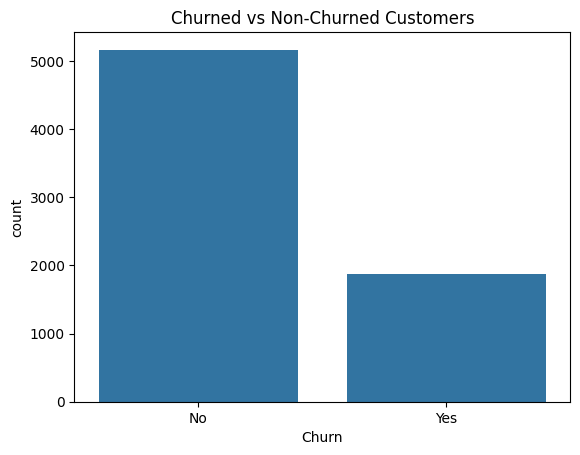

In [19]:
sns.countplot(data=df, x="Churn")
plt.title("Churned vs Non-Churned Customers")
plt.show()

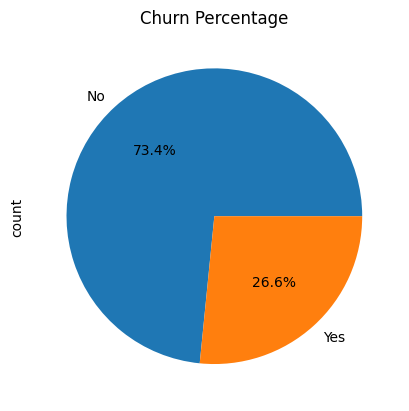

In [20]:
df["Churn"].value_counts().plot.pie(autopct="%1.1f%%")
plt.title("Churn Percentage")
plt.show()

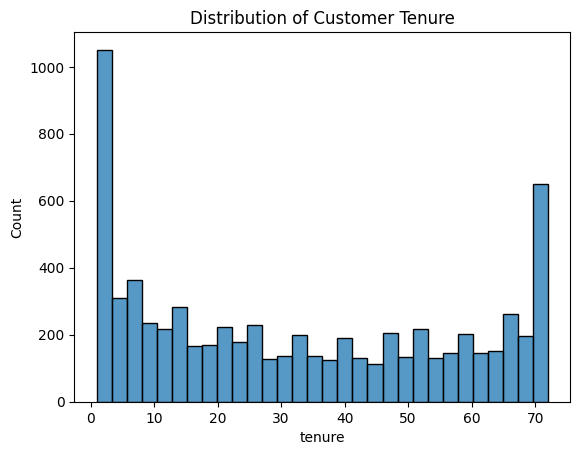

In [21]:
sns.histplot(df["tenure"], bins=30)
plt.title("Distribution of Customer Tenure")
plt.show()

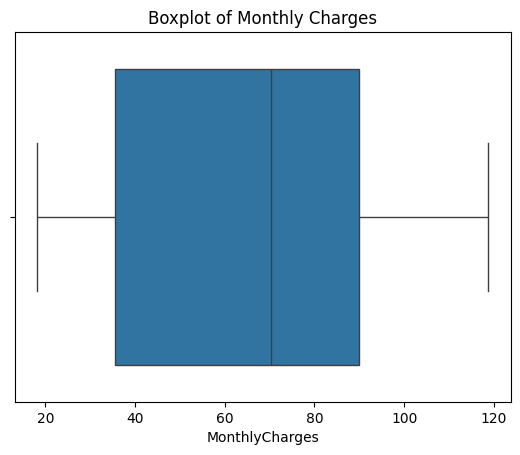

In [22]:
sns.boxplot(x=df["MonthlyCharges"])
plt.title("Boxplot of Monthly Charges")
plt.show()

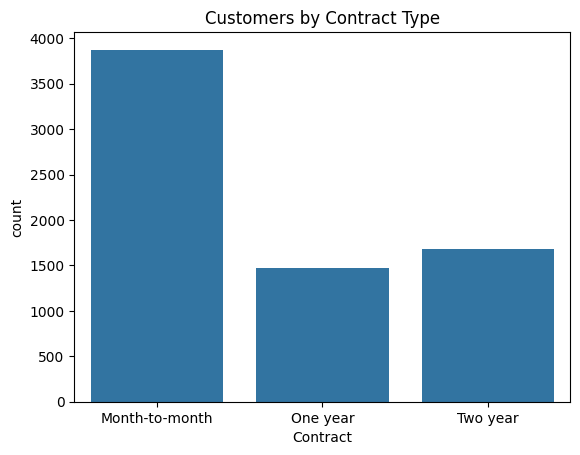

In [23]:
sns.countplot(data=df, x="Contract")
plt.title("Customers by Contract Type")
plt.show()

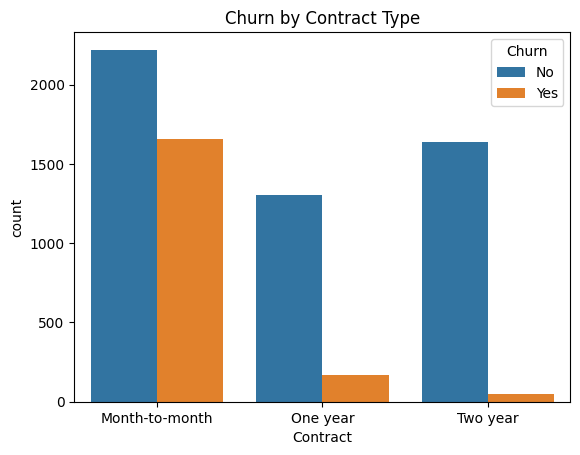

In [24]:
sns.countplot(data=df, x="Contract", hue="Churn")
plt.title("Churn by Contract Type")
plt.show()

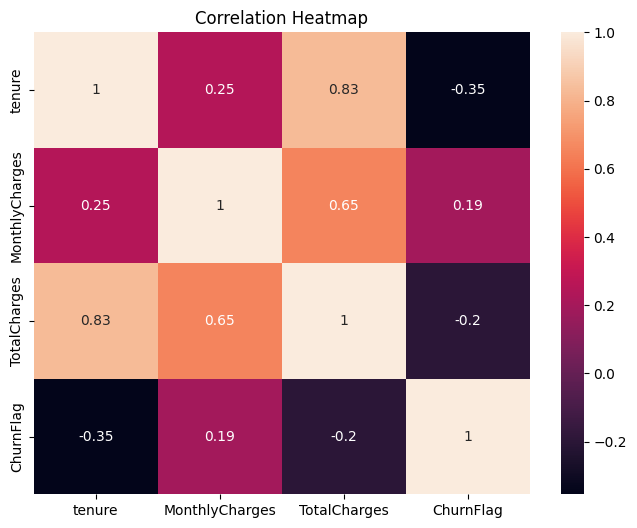

In [25]:
df["ChurnFlag"] = df["Churn"].map({"Yes": 1, "No": 0})
plt.figure(figsize=(8,6))
sns.heatmap(df[["tenure","MonthlyCharges","TotalCharges","ChurnFlag"]].corr(), annot=True)
plt.title("Correlation Heatmap")
plt.show()

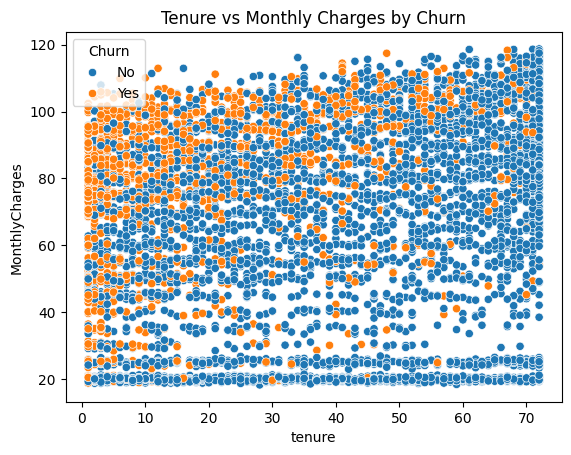

In [26]:
sns.scatterplot(data=df, x="tenure", y="MonthlyCharges", hue="Churn")
plt.title("Tenure vs Monthly Charges by Churn")
plt.show()

## Key Questions and Answers

**1. What percentage of customers churned?**
Out of 7,032 customers (after cleaning), 26.6% churned while 73.4% stayed, as shown in the churn percentage pie chart.

**2. Which customer group has the highest churn rate?**
Month-to-month contract customers have by far the highest churn, with churned customers nearly matching non-churned ones in that group. One-year and especially two-year contract customers churn far less, showing that longer contracts are strongly linked to customer retention.

**3. Which numerical features are most related to churn?**
Tenure has the strongest relationship with churn, with a correlation of -0.35, meaning customers who have been with the company longer are noticeably less likely to churn. TotalCharges has a weaker negative correlation (-0.2), and MonthlyCharges has a weak positive correlation (0.19), meaning customers paying more per month are slightly more likely to churn.

**4. Which categorical features are most related to churn?**
Contract type stands out as the strongest categorical factor, with month-to-month customers churning at a much higher rate than one-year or two-year customers.

**5. Did you find missing values or outliers?**
Yes. The TotalCharges column had 11 missing values after converting it to a numeric type; these rows were removed during cleaning, leaving 7,032 rows. The IQR-based outlier check found 0 outliers in MonthlyCharges, TotalCharges, and tenure, confirming there are no extreme values distorting the analysis.

**6. What are the top 3 factors driving churn?**
Based on the analysis, the top three factors are: 1) Contract type, since month-to-month customers churn far more than long-term contract customers, 2) Tenure, since newer customers are more likely to leave, and 3) Monthly charges, since customers with higher bills show a slightly higher tendency to churn.

**7. What would you recommend the business do?**
Since month-to-month customers churn the most, the business could offer discounts or incentives to encourage them to switch to one-year or two-year contracts. Since low-tenure customers are more likely to leave, improving the onboarding experience and engagement in the first few months could help reduce early churn.

**8. Conclusion**
Overall, the analysis shows that customers on month-to-month contracts with shorter tenure and higher monthly charges are the most likely to churn, while customers on longer contracts with longer tenure are far more likely to stay. Focusing retention efforts on contract upgrades and early customer engagement could meaningfully reduce churn.